In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

In [33]:
path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]
Total trials: 289
Stim trials: 146
Catch trials: 143


In [34]:
Bin_size = 0.01 # 10 ms bins
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Total spikes in AP: 431640.0


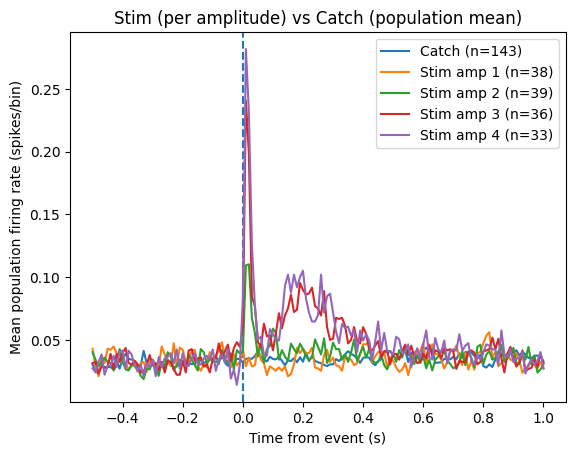

In [35]:
amps_stim = [1,2,3,4]

def event_triggered_matrix(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    mats = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        mats.append(AP_Bin_Matrx[:, pt1:pt2+1].astype(np.float32))  # (n_neurons, W)
    if len(mats) == 0:
        return None, 0
    return np.stack(mats, axis=0), len(mats)  # (n_trials, n_neurons, W)

# event-triggered mean
def event_triggered_mean(AP_Bin_Matrx, event_times, AP_Bin_Resolution, pre_bins=50, post_bins=100):
    W = pre_bins + post_bins + 1
    M = np.zeros((AP_Bin_Matrx.shape[0], W), dtype=np.float32)
    n = 0
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        pt1, pt2 = pt - pre_bins, pt + post_bins
        if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
            continue
        M += AP_Bin_Matrx[:, pt1:pt2+1]
        n += 1
    return M / max(n, 1), n

# stim times par amplitude
stim_sel = tr["whisker_stim_time"].notna() & tr["whisker_stim_amplitude"].isin(amps_stim)

Stim_times_by_amp = {
    a: np.sort(tr.loc[stim_sel & (tr["whisker_stim_amplitude"] == a), "whisker_stim_time"].to_numpy())
    for a in amps_stim
}

catch_sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
Catch_times = np.sort((tr.loc[catch_sel, "no_stim_time"]).to_numpy())

pre_bins, post_bins = 50, 100
time_axis = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size

CATCH_MTRX, n_catch = event_triggered_mean(AP_Bin_Matrx, Catch_times, AP_Bin_Resolution, pre_bins, post_bins)

plt.figure()
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label=f"Catch (n={n_catch})")
plt.axvline(0, linestyle="--")

for a in amps_stim:
    STM, n_st = event_triggered_mean(AP_Bin_Matrx, Stim_times_by_amp[a], AP_Bin_Resolution, pre_bins, post_bins)
    plt.plot(time_axis, STM.mean(axis=0), label=f"Stim amp {a} (n={n_st})")

plt.xlabel("Time from event (s)")
plt.ylabel("Mean population firing rate (spikes/bin)")
plt.title("Stim (per amplitude) vs Catch (population mean)")
plt.legend()
plt.show()

lololooloolorkfieornfiubernfrew

In [36]:
Pop_Vect_Stim = STM[:, 50:60].mean(axis=1)  # a voir
Pop_Vect_Catch = CATCH_MTRX[:, 50:60].mean(axis=1) # a voir

CD_Stim = Pop_Vect_Stim - Pop_Vect_Catch
CD_Stim = CD_Stim / (np.linalg.norm(CD_Stim) + 1e-12)

print("CD_Stim norm:", np.linalg.norm(CD_Stim), "shape:", CD_Stim.shape)

Projected_Act_CD_Stim = CD_Stim @ AP_Bin_Matrx
print(Projected_Act_CD_Stim.shape)

CD_Stim norm: 1.0 shape: (30,)
(388288,)


V1 built from 38 trials
V2 built from 39 trials
V3 built from 36 trials
V4 built from 33 trials
V_noise built from 143 catch trials

sim(V4, V_noise) = 0.468
sim(V1, V4) = 0.577
sim(V2, V4) = 0.882
sim(V3, V4) = 0.986
sim(V4, V4) = 1.000


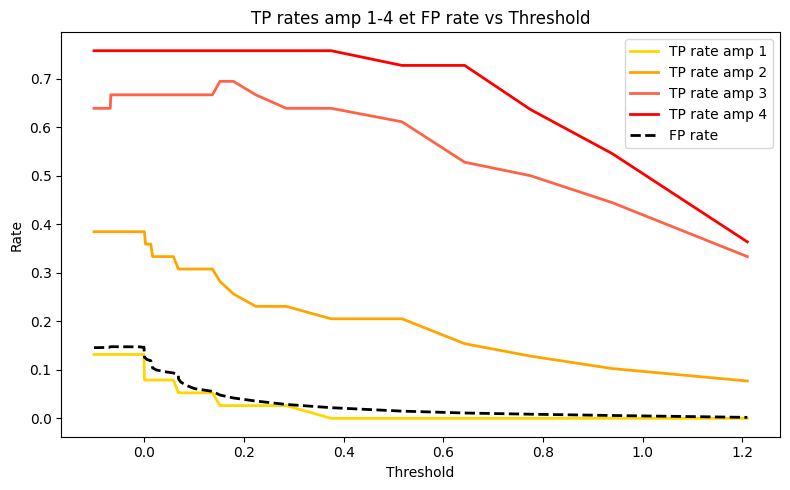

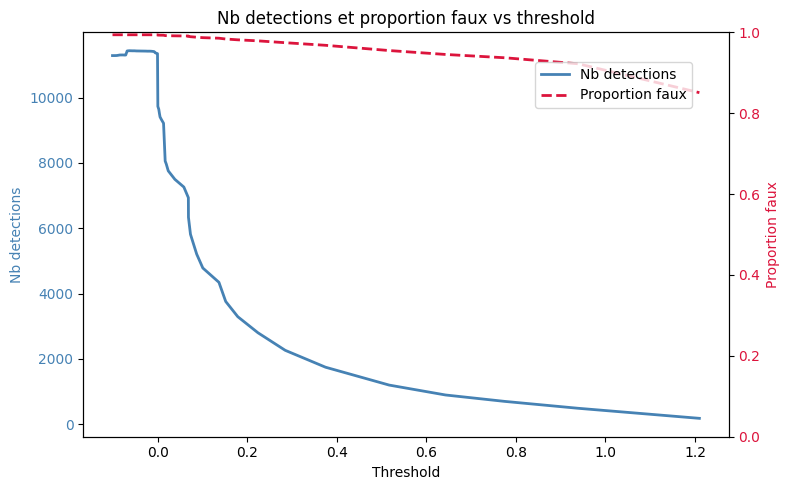


best threshold : 0.3746
  amp 1: TP=0.000   FP rate=0.022   prop faux=0.968
  amp 2: TP=0.205   FP rate=0.022   prop faux=0.968
  amp 3: TP=0.639   FP rate=0.022   prop faux=0.968
  amp 4: TP=0.758   FP rate=0.022   prop faux=0.968


In [37]:

W = 3 # taille fenetre pr template -> 30 ms
amps_eval = [1, 2, 3, 4]

# templates
V = {}
for a in amps_eval:
    resp = []
    for ev in Stim_times_by_amp[a]:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt + W > AP_Bin_Matrx.shape[1]:
            continue
        resp.append(AP_Bin_Matrx[:, pt:pt + W].mean(axis=1))
    Va = np.mean(resp, axis=0).astype(np.float32)
    V[a] = Va / (np.linalg.norm(Va) + 1e-12)
    print(f"V{a} built from {len(resp)} trials")

resp_noise = []
for ev in Catch_times:
    pt = int(np.round(ev * AP_Bin_Resolution))
    if pt + W > AP_Bin_Matrx.shape[1]:
        continue
    resp_noise.append(AP_Bin_Matrx[:, pt:pt + W].mean(axis=1))
V_noise = np.mean(resp_noise, axis=0).astype(np.float32)
V_noise = V_noise / (np.linalg.norm(V_noise) + 1e-12)
print(f"V_noise built from {len(resp_noise)} catch trials")

print(f"\nsim(V4, V_noise) = {float(V[4] @ V_noise):.3f}")
for a in amps_eval:
    print(f"sim(V{a}, V4) = {float(V[a] @ V[4]):.3f}")

# score
V4 = V[4]

cs    = np.cumsum(AP_Bin_Matrx, axis=1, dtype=np.float64)
cs    = np.concatenate([np.zeros((AP_Bin_Matrx.shape[0], 1)), cs], axis=1)
AP_ma = (cs[:, W:] - cs[:, :-W]) / W
x      = AP_ma.astype(np.float32)
x_norm = np.linalg.norm(x, axis=0)
x_unit = x / (x_norm + 1e-12)

score = (V4 @ x_unit - V_noise @ x_unit) * x_norm
t_sig = np.arange(AP_ma.shape[1]) * Bin_size

# detection
refractory_s = 0.2 # eviter de détecter 2 fois un même événement
tol_post     = 0.05
t_start      = float(tr["start_time"].min())
t_end        = float(tr["stop_time"].max())

def detect_peaks(score, t, thr, refractory_s, Bin_size, t_start, t_end):
    mask   = (t >= t_start) & (t <= t_end) & (score > thr)
    idx    = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = int(np.round(refractory_s / Bin_size))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:
            keep.append(p)
        elif score[p] > score[keep[-1]]:
            keep[-1] = p
    return t[np.array(keep, dtype=int)]

# threshold sweep
in_range = (t_sig >= t_start) & (t_sig <= t_end)
ths      = np.percentile(score[in_range], np.linspace(50, 99.9, 80))

all_stim_times = np.sort(np.concatenate([Stim_times_by_amp[a] for a in amps_eval]))
all_stim       = all_stim_times
non_stim_dur   = (t_end - t_start) - len(all_stim_times) * tol_post
n_fp_windows   = max(non_stim_dur / tol_post, 1)

tp_curves     = {a: [] for a in amps_eval}
fp_rate_curve = []
fp_prop_curve = []
n_det_curve   = []

for thr in ths:
    det_t = detect_peaks(score, t_sig, thr, refractory_s, Bin_size, t_start, t_end)

    in_win_all = np.zeros(len(det_t), dtype=bool)
    for st in all_stim_times:
        in_win_all |= (det_t >= st) & (det_t <= st + tol_post)

    n_fp = int(np.sum(~in_win_all))
    fp_rate_curve.append(n_fp / n_fp_windows)
    fp_prop_curve.append(n_fp / max(len(det_t), 1))
    n_det_curve.append(len(det_t))

    for a in amps_eval:
        hits = sum(
            np.any((det_t >= st) & (det_t <= st + tol_post))
            for st in Stim_times_by_amp[a]
        )
        tp_curves[a].append(hits / max(len(Stim_times_by_amp[a]), 1))

tp_curves     = {a: np.array(tp_curves[a])     for a in amps_eval}
fp_rate_curve = np.array(fp_rate_curve)
fp_prop_curve = np.array(fp_prop_curve)
n_det_curve   = np.array(n_det_curve, dtype=float)

# plot TP et FP
colors_amp = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}

plt.figure(figsize=(8, 5))
for a in amps_eval:
    plt.plot(ths, tp_curves[a], color=colors_amp[a], lw=2, label=f"TP rate amp {a}")
plt.plot(ths, fp_rate_curve, linestyle="--", color="black", lw=2, label="FP rate")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("TP rates amp 1-4 et FP rate vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# plot nb detections et proportion faux
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(ths, n_det_curve, color="steelblue", lw=2, label="Nb detections")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Nb detections", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2 = ax1.twinx()
ax2.plot(ths, fp_prop_curve, color="crimson", linestyle="--", lw=2, label="Proportion faux")
ax2.set_ylabel("Proportion faux", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 1)
plt.title("Nb detections et proportion faux vs threshold")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

best = np.argmax(tp_curves[4] - fp_rate_curve)
print(f"\nbest threshold : {ths[best]:.4f}")
for a in amps_eval:
    print(f"  amp {a}: TP={tp_curves[a][best]:.3f}   FP rate={fp_rate_curve[best]:.3f}   prop faux={fp_prop_curve[best]:.3f}")


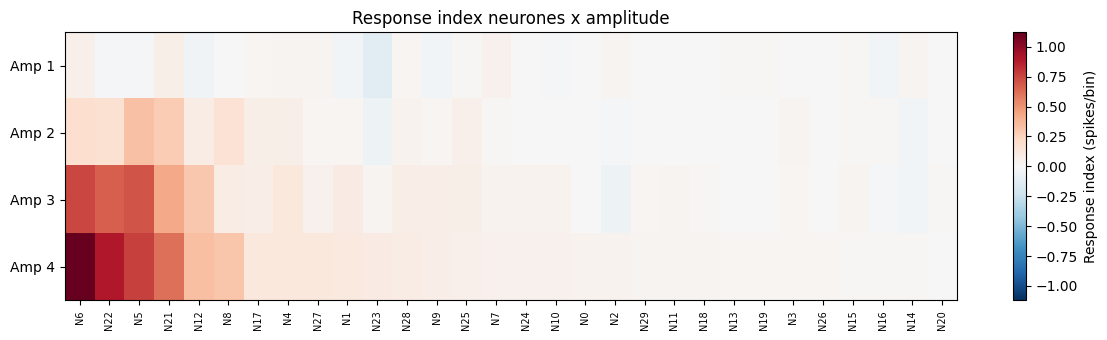

top 5 neurones par amplitude
  amp 1: neurones [21, 6, 7, 14, 27]  RI = [0.061 0.053 0.044 0.026 0.026]
  amp 2: neurones [5, 21, 6, 22, 8]  RI = [0.325 0.282 0.188 0.171 0.162]
  amp 3: neurones [6, 5, 22, 21, 12]  RI = [0.75  0.704 0.667 0.426 0.306]
  amp 4: neurones [6, 22, 5, 21, 12]  RI = [1.121 0.899 0.768 0.616 0.333]

best threshold : 0.3746
  TP amp4 : 25   FP : 1690


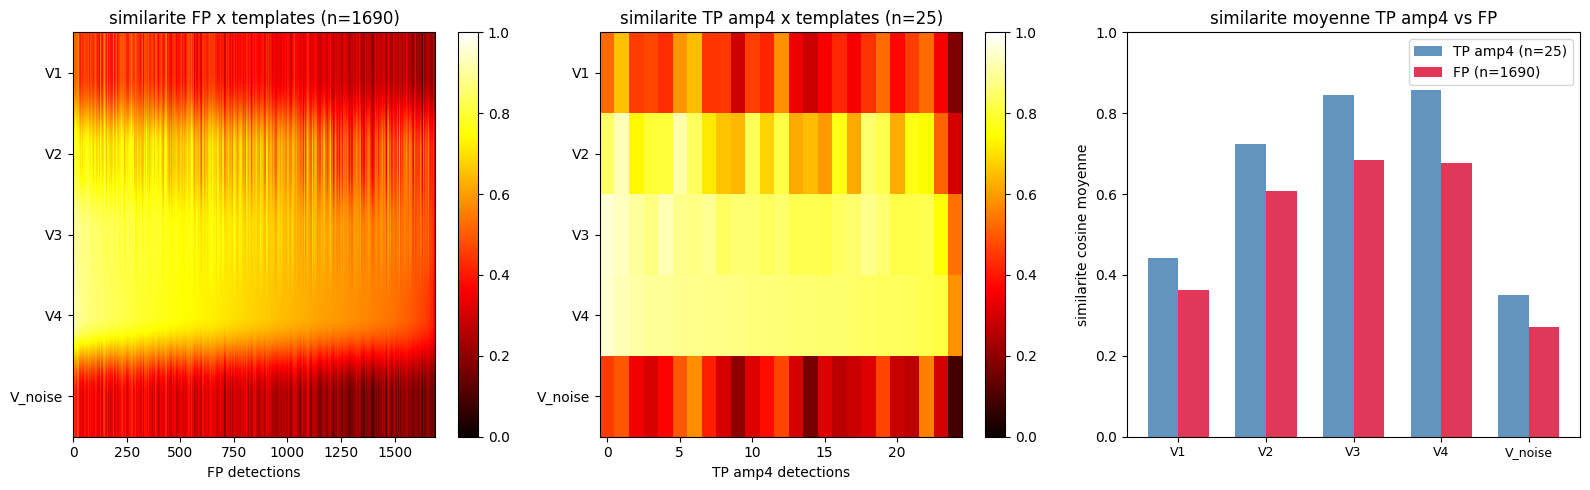


similarite moyenne FP
  V1: 0.363
  V2: 0.608
  V3: 0.685
  V4: 0.677
  V_noise: 0.271

similarite moyenne TP amp4
  V1: 0.442
  V2: 0.723
  V3: 0.845
  V4: 0.857
  V_noise: 0.350


In [38]:

# response index
response_index = {}
for a in amps_eval:
    ri = []
    for ev in Stim_times_by_amp[a]:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - W < 0 or pt + W > AP_Bin_Matrx.shape[1]:
            continue
        post_act = AP_Bin_Matrx[:, pt:pt + W].mean(axis=1)
        base_act = AP_Bin_Matrx[:, pt - W:pt].mean(axis=1)
        ri.append(post_act - base_act)
    response_index[a] = np.mean(ri, axis=0) if ri else np.zeros(AP_Bin_Matrx.shape[0])

# tri par amp4
sort_idx  = np.argsort(response_index[4])[::-1]
ri_matrix = np.array([response_index[a][sort_idx] for a in amps_eval])

fig, ax = plt.subplots(figsize=(12, 3.5))
lim = np.abs(ri_matrix).max()
im  = ax.imshow(ri_matrix, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
ax.set_xticks(range(AP_Bin_Matrx.shape[0]))
ax.set_xticklabels([f"N{sort_idx[i]}" for i in range(AP_Bin_Matrx.shape[0])], rotation=90, fontsize=7)
ax.set_yticks(range(len(amps_eval)))
ax.set_yticklabels([f"Amp {a}" for a in amps_eval])
plt.colorbar(im, ax=ax, label="Response index (spikes/bin)")
ax.set_title("Response index neurones x amplitude")
plt.tight_layout()
plt.show()

print("top 5 neurones par amplitude")
for a in amps_eval:
    top5 = np.argsort(response_index[a])[::-1][:5]
    print(f"  amp {a}: neurones {list(top5)}  RI = {response_index[a][top5].round(3)}")

# vecteurs population
best_idx  = np.argmax(tp_curves[4] - fp_rate_curve)
thr_best  = ths[best_idx]
det_all   = detect_peaks(score, t_sig, thr_best, refractory_s, Bin_size, t_start, t_end)

in_win_all = np.zeros(len(det_all), dtype=bool)
for st in all_stim_times:
    in_win_all |= (det_all >= st) & (det_all <= st + tol_post)
fp_times_diag = det_all[~in_win_all]

in_win4 = np.zeros(len(det_all), dtype=bool)
for st in Stim_times_by_amp[4]:
    in_win4 |= (det_all >= st) & (det_all <= st + tol_post)
tp4_det = det_all[in_win4]

print(f"\nbest threshold : {thr_best:.4f}")
print(f"  TP amp4 : {len(tp4_det)}   FP : {len(fp_times_diag)}")

def get_pop_vectors(times, AP_Bin_Matrx, AP_Bin_Resolution, W):
    vecs = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt + W > AP_Bin_Matrx.shape[1]:
            continue
        v = AP_Bin_Matrx[:, pt:pt + W].mean(axis=1).astype(np.float32)
        vecs.append(v)
    return np.array(vecs) if vecs else np.zeros((0, AP_Bin_Matrx.shape[0]), dtype=np.float32)

def normalize_rows(M):
    return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-12)

fp_vecs  = get_pop_vectors(fp_times_diag, AP_Bin_Matrx, AP_Bin_Resolution, W)
tp4_vecs = get_pop_vectors(tp4_det,       AP_Bin_Matrx, AP_Bin_Resolution, W)

fp_unit  = normalize_rows(fp_vecs)  if len(fp_vecs)  > 0 else fp_vecs
tp4_unit = normalize_rows(tp4_vecs) if len(tp4_vecs) > 0 else tp4_vecs

# similarite avec chaque template
tmpl_labels = [f"V{a}" for a in amps_eval] + ["V_noise"]
templates   = np.array([V[a] for a in amps_eval] + [V_noise], dtype=np.float32)

sim_fp  = fp_unit  @ templates.T if len(fp_vecs)  > 0 else np.zeros((0, len(tmpl_labels)))
sim_tp4 = tp4_unit @ templates.T if len(tp4_vecs) > 0 else np.zeros((0, len(tmpl_labels)))

sim_fp_mean  = sim_fp.mean(axis=0)  if len(sim_fp)  > 0 else np.zeros(len(tmpl_labels))
sim_tp4_mean = sim_tp4.mean(axis=0) if len(sim_tp4) > 0 else np.zeros(len(tmpl_labels))

# matrices similarite
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sort_fp  = np.argsort(sim_fp[:, 3])[::-1]  if len(sim_fp)  > 0 else np.array([], dtype=int)
sort_tp4 = np.argsort(sim_tp4[:, 3])[::-1] if len(sim_tp4) > 0 else np.array([], dtype=int)

data_fp  = sim_fp[sort_fp]   if len(sort_fp)  > 0 else np.zeros((1, len(tmpl_labels)))
data_tp4 = sim_tp4[sort_tp4] if len(sort_tp4) > 0 else np.zeros((1, len(tmpl_labels)))

im0 = axes[0].imshow(data_fp.T, aspect="auto", cmap="hot", vmin=0, vmax=1)
axes[0].set_yticks(range(len(tmpl_labels)))
axes[0].set_yticklabels(tmpl_labels)
axes[0].set_xlabel("FP detections")
axes[0].set_title(f"similarite FP x templates (n={len(fp_times_diag)})")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(data_tp4.T, aspect="auto", cmap="hot", vmin=0, vmax=1)
axes[1].set_yticks(range(len(tmpl_labels)))
axes[1].set_yticklabels(tmpl_labels)
axes[1].set_xlabel("TP amp4 detections")
axes[1].set_title(f"similarite TP amp4 x templates (n={len(tp4_det)})")
plt.colorbar(im1, ax=axes[1])

x_pos = np.arange(len(tmpl_labels))
width = 0.35
axes[2].bar(x_pos - width/2, sim_tp4_mean, width, color="steelblue", alpha=0.85, label=f"TP amp4 (n={len(tp4_vecs)})")
axes[2].bar(x_pos + width/2, sim_fp_mean,  width, color="crimson",   alpha=0.85, label=f"FP (n={len(fp_vecs)})")
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(tmpl_labels, fontsize=9)
axes[2].set_ylabel("similarite cosine moyenne")
axes[2].set_ylim(0, 1)
axes[2].set_title("similarite moyenne TP amp4 vs FP")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nsimilarite moyenne FP")
for i, lbl in enumerate(tmpl_labels):
    print(f"  {lbl}: {sim_fp_mean[i]:.3f}")
print("\nsimilarite moyenne TP amp4")
for i, lbl in enumerate(tmpl_labels):
    print(f"  {lbl}: {sim_tp4_mean[i]:.3f}")


TP amp4 : 25   FP : 9662


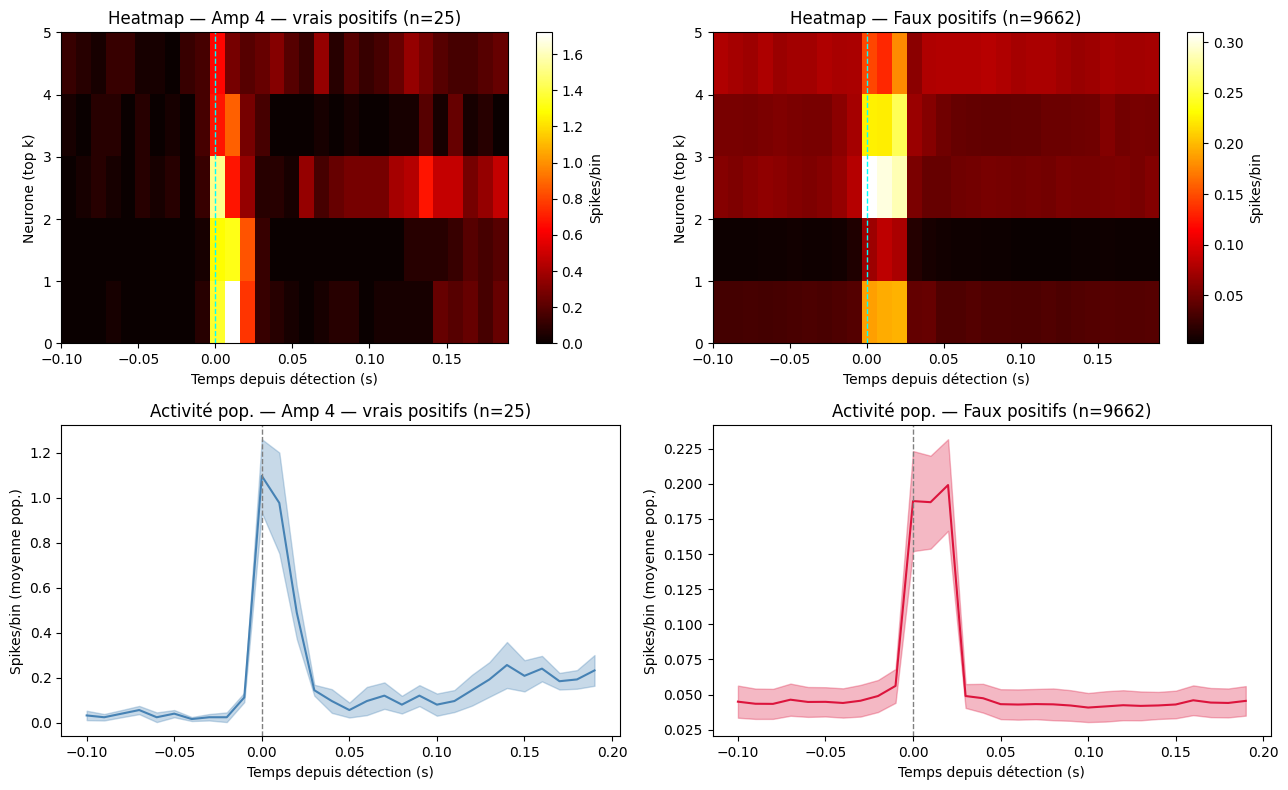

In [42]:

# amp4 (TP) vs faux positifs
AP_sel = AP_Bin_Matrx[sort_idx[:5], :]  # top 5 neurones triés par RI amp4

thr_diag = np.percentile(score[in_range], 80)
det_diag = detect_peaks(score, t_sig, thr_diag, refractory_s, Bin_size, t_start, t_end)

in_win_diag = np.zeros(len(det_diag), dtype=bool)
for st in all_stim:
    in_win_diag |= (det_diag >= st) & (det_diag <= st + tol_post)

fp_times = det_diag[~in_win_diag]

in_win_tp4 = np.zeros(len(det_diag), dtype=bool)
for st in Stim_times_by_amp[4]:
    in_win_tp4 |= (det_diag >= st) & (det_diag <= st + tol_post)
tp4_times = det_diag[in_win_tp4]

print(f"TP amp4 : {len(tp4_times)}   FP : {len(fp_times)}")

pre, post = 10, 20
t_win = (np.arange(pre + post) - pre) * Bin_size

def extract_segments(AP_sel, times, AP_Bin_Resolution, pre, post):
    segs = []
    for ev in times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - pre < 0 or pt + post > AP_sel.shape[1]:
            continue
        segs.append(AP_sel[:, pt - pre:pt + post])
    return np.array(segs) if segs else None

segs_tp4 = extract_segments(AP_sel, tp4_times, AP_Bin_Resolution, pre, post)
segs_fp  = extract_segments(AP_sel, fp_times,  AP_Bin_Resolution, pre, post)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col, (segs, label, color) in enumerate([
        (segs_tp4, f"Amp 4 — vrais positifs (n={len(tp4_times)})", "steelblue"),
        (segs_fp,  f"Faux positifs (n={len(fp_times)})",           "crimson")]):

    if segs is None:
        continue

    mean_act = segs.mean(axis=0)

    ax = axes[0, col]
    im = ax.imshow(mean_act, aspect="auto", origin="lower",
                   extent=[t_win[0], t_win[-1], 0, mean_act.shape[0]],
                   cmap="hot")
    ax.axvline(0, color="cyan", lw=1, linestyle="--")
    ax.set_xlabel("Temps depuis détection (s)")
    ax.set_ylabel("Neurone (top k)")
    ax.set_title(f"Heatmap — {label}")
    plt.colorbar(im, ax=ax, label="Spikes/bin")

    ax = axes[1, col]
    ax.plot(t_win, mean_act.mean(axis=0), color=color, lw=1.5)
    ax.fill_between(t_win,
                    mean_act.mean(axis=0) - mean_act.std(axis=0) / np.sqrt(mean_act.shape[0]),
                    mean_act.mean(axis=0) + mean_act.std(axis=0) / np.sqrt(mean_act.shape[0]),
                    alpha=0.3, color=color)
    ax.axvline(0, color="gray", lw=1, linestyle="--")
    ax.set_xlabel("Temps depuis détection (s)")
    ax.set_ylabel("Spikes/bin (moyenne pop.)")
    ax.set_title(f"Activité pop. — {label}")

plt.tight_layout()
plt.show()


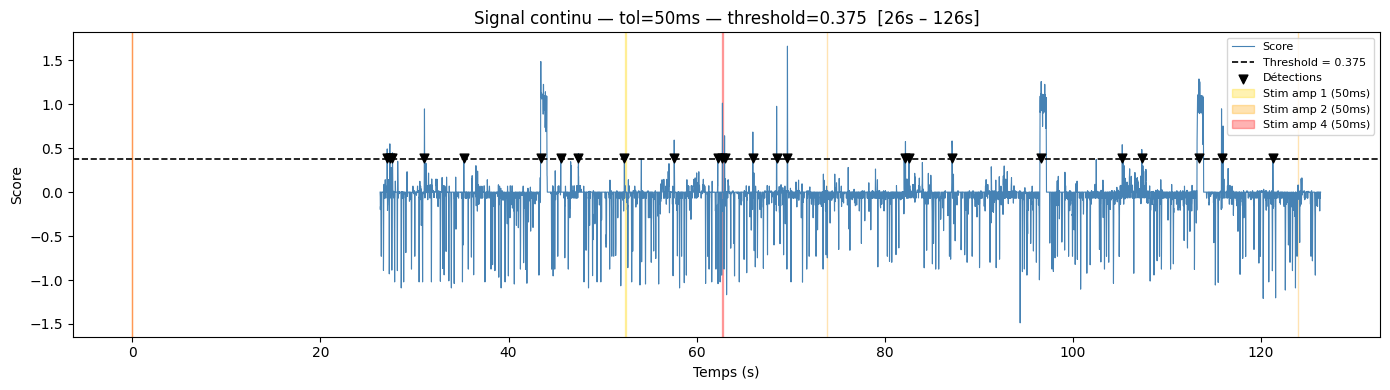

Threshold : 0.3746  |  TP amp4=0.758  FP=0.022


In [43]:

# Signal + threshold + vrais stims 

best_idx = np.argmax(tp_curves[4] - fp_rate_curve)
thr_plot = ths[best_idx]

det_t = detect_peaks(score, t_sig, thr_plot, refractory_s, Bin_size, t_start, t_end)

t_zoom_start = t_start
t_zoom_end   = t_zoom_start + 100
mask_zoom    = (t_sig >= t_zoom_start) & (t_sig <= t_zoom_end)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t_sig[mask_zoom], score[mask_zoom], color="steelblue", lw=0.8, label="Score")
ax.axhline(thr_plot, color="black", linestyle="--", lw=1.2, label=f"Threshold = {thr_plot:.3f}")

det_zoom = det_t[(det_t >= t_zoom_start) & (det_t <= t_zoom_end)]
ax.scatter(det_zoom, np.full_like(det_zoom, thr_plot * 1.05), marker="v", color="black", s=40, zorder=5, label="Détections")

colors = {1: "gold", 2: "orange", 3: "tomato", 4: "red"}
for a in amps_eval:
    stims_zoom = Stim_times_by_amp[a]
    stims_zoom = stims_zoom[(stims_zoom >= t_zoom_start) & (stims_zoom <= t_zoom_end)]
    for st in stims_zoom:
        ax.axvspan(st, st + tol_post, alpha=0.3, color=colors[a])
    if len(stims_zoom) > 0:
        ax.axvspan(0, 0, alpha=0.3, color=colors[a], label=f"Stim amp {a} (50ms)")

ax.set_xlabel("Temps (s)")
ax.set_ylabel("Score")
ax.set_title(f"Signal continu — tol=50ms — threshold={thr_plot:.3f}  [{t_zoom_start:.0f}s – {t_zoom_end:.0f}s]")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Threshold : {thr_plot:.4f}  |  TP amp4={tp_curves[4][best_idx]:.3f}  FP={fp_rate_curve[best_idx]:.3f}")


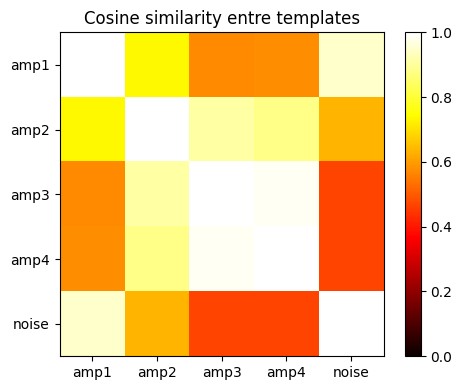

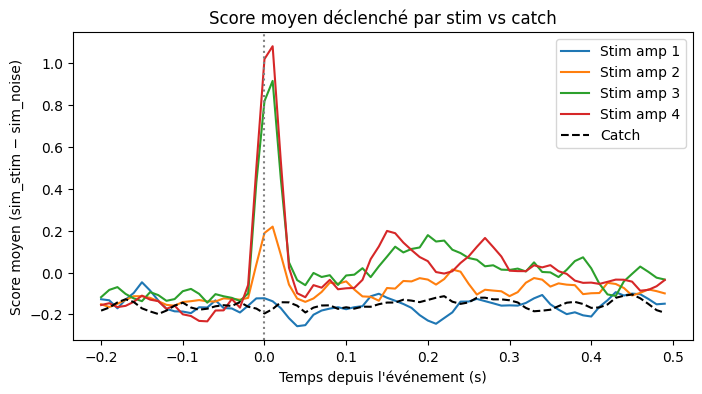

In [44]:

# 1. Similarité entre templates (matrice)
all_labels = amps_eval + ["noise"]
all_vecs   = [V[a] for a in amps_eval] + [V_noise]

sim_matrix = np.array([[float(u @ v) for v in all_vecs] for u in all_vecs])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap="hot")
ax.set_xticks(range(len(all_labels))); ax.set_xticklabels([f"amp{a}" if a != "noise" else "noise" for a in all_labels])
ax.set_yticks(range(len(all_labels))); ax.set_yticklabels([f"amp{a}" if a != "noise" else "noise" for a in all_labels])
plt.colorbar(im, ax=ax)
ax.set_title("Cosine similarity entre templates")
plt.tight_layout()
plt.show()

# 2. Distribution du score autour des stims vs catch
pre_bins_diag, post_bins_diag = 20, 50
time_ax_diag = (np.arange(pre_bins_diag + post_bins_diag) - pre_bins_diag) * Bin_size

def triggered_mean_1d(signal, event_times, AP_Bin_Resolution, pre, post):
    segs = []
    for ev in event_times:
        pt = int(np.round(ev * AP_Bin_Resolution))
        if pt - pre < 0 or pt + post > len(signal):
            continue
        segs.append(signal[pt - pre: pt + post])
    return np.mean(segs, axis=0) if segs else None

score_stim = {a: triggered_mean_1d(score, Stim_times_by_amp[a], AP_Bin_Resolution, pre_bins_diag, post_bins_diag) for a in amps_eval}
score_catch = triggered_mean_1d(score, Catch_times, AP_Bin_Resolution, pre_bins_diag, post_bins_diag)

plt.figure(figsize=(8, 4))
for a in amps_eval:
    if score_stim[a] is not None:
        plt.plot(time_ax_diag, score_stim[a], label=f"Stim amp {a}")
if score_catch is not None:
    plt.plot(time_ax_diag, score_catch, linestyle="--", color="black", label="Catch")
plt.axvline(0, linestyle=":", color="gray")
plt.xlabel("Temps depuis l'événement (s)")
plt.ylabel("Score moyen (sim_stim − sim_noise)")
plt.title("Score moyen déclenché par stim vs catch")
plt.legend()
plt.show()
